In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [21]:
df = pd.read_csv('vehiculos.csv')
df

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad,categoria
0,muy_alto,muy_alto,2,2,pequeno,media,inaceptable
1,muy_alto,muy_alto,2,2,pequeno,alta,inaceptable
2,muy_alto,muy_alto,2,2,mediano,baja,inaceptable
3,muy_alto,muy_alto,2,2,mediano,media,inaceptable
4,muy_alto,muy_alto,2,2,mediano,alta,inaceptable
...,...,...,...,...,...,...,...
1722,bajo,bajo,5+,4+,mediano,media,bueno
1723,bajo,bajo,5+,4+,mediano,alta,muy_bueno
1724,bajo,bajo,5+,4+,grande,baja,inaceptable
1725,bajo,bajo,5+,4+,grande,media,bueno


In [22]:
#datos faltates
df.isnull().sum()

precio           0
mantenimiento    0
nro_puertas      0
pasajeros        0
baul             0
seguridad        0
categoria        0
dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   precio         1727 non-null   object
 1   mantenimiento  1727 non-null   object
 2   nro_puertas    1727 non-null   object
 3   pasajeros      1727 non-null   object
 4   baul           1727 non-null   object
 5   seguridad      1727 non-null   object
 6   categoria      1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [24]:
#informacion variables categoricas
for col in df.columns:
    print(df[col].value_counts())
    print('-'*20)

precio
alto        432
medio       432
bajo        432
muy_alto    431
Name: count, dtype: int64
--------------------
mantenimiento
alto        432
medio       432
bajo        432
muy_alto    431
Name: count, dtype: int64
--------------------
nro_puertas
3     432
4     432
5+    432
2     431
Name: count, dtype: int64
--------------------
pasajeros
4     576
4+    576
2     575
Name: count, dtype: int64
--------------------
baul
mediano    576
grande     576
pequeno    575
Name: count, dtype: int64
--------------------
seguridad
media    576
alta     576
baja     575
Name: count, dtype: int64
--------------------
categoria
inaceptable    1209
aceptable       384
bueno            69
muy_bueno        65
Name: count, dtype: int64
--------------------


In [25]:
#caracteristica (o variables predictorias)
x = df.iloc[:,:-1]
x

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad
0,muy_alto,muy_alto,2,2,pequeno,media
1,muy_alto,muy_alto,2,2,pequeno,alta
2,muy_alto,muy_alto,2,2,mediano,baja
3,muy_alto,muy_alto,2,2,mediano,media
4,muy_alto,muy_alto,2,2,mediano,alta
...,...,...,...,...,...,...
1722,bajo,bajo,5+,4+,mediano,media
1723,bajo,bajo,5+,4+,mediano,alta
1724,bajo,bajo,5+,4+,grande,baja
1725,bajo,bajo,5+,4+,grande,media


In [26]:
y = df.iloc[:,:-1]
y

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad
0,muy_alto,muy_alto,2,2,pequeno,media
1,muy_alto,muy_alto,2,2,pequeno,alta
2,muy_alto,muy_alto,2,2,mediano,baja
3,muy_alto,muy_alto,2,2,mediano,media
4,muy_alto,muy_alto,2,2,mediano,alta
...,...,...,...,...,...,...
1722,bajo,bajo,5+,4+,mediano,media
1723,bajo,bajo,5+,4+,mediano,alta
1724,bajo,bajo,5+,4+,grande,baja
1725,bajo,bajo,5+,4+,grande,media


In [27]:
#partir en entrenamientovalidacion y prueba
from sklearn.model_selection import train_test_split
# usar la columna target correcta
y = df[col]  # 'categoria'
x_trvl, x_ts, y_trvl, y_ts = train_test_split(x, y, test_size=0.1, random_state=123, stratify=y)

print('tamaño set de entrenamiento y validacion:', x_trvl.shape, y_trvl.shape)
print(y_trvl.value_counts(normalize=True))



print('proporcion de categorias en el set de pruebas: ')
print(y_ts.value_counts(normalize=True))


tamaño set de entrenamiento y validacion: (1554, 6) (1554,)
categoria
inaceptable    0.700129
aceptable      0.222651
bueno          0.039897
muy_bueno      0.037323
Name: proportion, dtype: float64
proporcion de categorias en el set de pruebas: 
categoria
inaceptable    0.699422
aceptable      0.219653
bueno          0.040462
muy_bueno      0.040462
Name: proportion, dtype: float64


In [28]:
print(x)

        precio mantenimiento nro_puertas pasajeros     baul seguridad
0     muy_alto      muy_alto           2         2  pequeno     media
1     muy_alto      muy_alto           2         2  pequeno      alta
2     muy_alto      muy_alto           2         2  mediano      baja
3     muy_alto      muy_alto           2         2  mediano     media
4     muy_alto      muy_alto           2         2  mediano      alta
...        ...           ...         ...       ...      ...       ...
1722      bajo          bajo          5+        4+  mediano     media
1723      bajo          bajo          5+        4+  mediano      alta
1724      bajo          bajo          5+        4+   grande      baja
1725      bajo          bajo          5+        4+   grande     media
1726      bajo          bajo          5+        4+   grande      alta

[1727 rows x 6 columns]


In [29]:
#codificacion ordinal de las variables predictorias
#nota importante: se define la codifciacion con base en el set de entrenamiento/validacion
#pues es el set de datos "conocido" (el otro se mantiene "oculto")
from sklearn.preprocessing import OrdinalEncoder

#codificar el set de entrenamiento/validacion ("x_trvl")
x_encoder = OrdinalEncoder()
X = x_encoder.fit_transform(x_trvl)

#veamos las categorias tenidas en cuenta por el decodificador y el resulrado de la codficicacion
print(x_encoder.categories_)
print(x)

[array(['alto', 'bajo', 'medio', 'muy_alto'], dtype=object), array(['alto', 'bajo', 'medio', 'muy_alto'], dtype=object), array(['2', '3', '4', '5+'], dtype=object), array(['2', '4', '4+'], dtype=object), array(['grande', 'mediano', 'pequeno'], dtype=object), array(['alta', 'baja', 'media'], dtype=object)]
        precio mantenimiento nro_puertas pasajeros     baul seguridad
0     muy_alto      muy_alto           2         2  pequeno     media
1     muy_alto      muy_alto           2         2  pequeno      alta
2     muy_alto      muy_alto           2         2  mediano      baja
3     muy_alto      muy_alto           2         2  mediano     media
4     muy_alto      muy_alto           2         2  mediano      alta
...        ...           ...         ...       ...      ...       ...
1722      bajo          bajo          5+        4+  mediano     media
1723      bajo          bajo          5+        4+  mediano      alta
1724      bajo          bajo          5+        4+   grande    

In [30]:
#al igual que en el caso anterior, se usa unicamente el set de entrenamiento/validacion
from sklearn.preprocessing import LabelEncoder

# instanciar LabelEncoder antes de usar fit_transform
y_encoder = LabelEncoder()
Y = y_encoder.fit_transform(y_trvl)

#veamos las categorias tenidas en cuenta por el decodificador y el resulrado de la codficicacion
print(y_encoder.classes_)
print(Y)


['aceptable' 'bueno' 'inaceptable' 'muy_bueno']
[0 2 2 ... 2 1 0]


In [31]:
from sklearn.tree import DecisionTreeClassifier

#crea instancia del clasificador y entrenar con el set de entrenamiento/validacion
arbol = DecisionTreeClassifier()
arbol.fit(X, Y)


DecisionTreeClassifier()

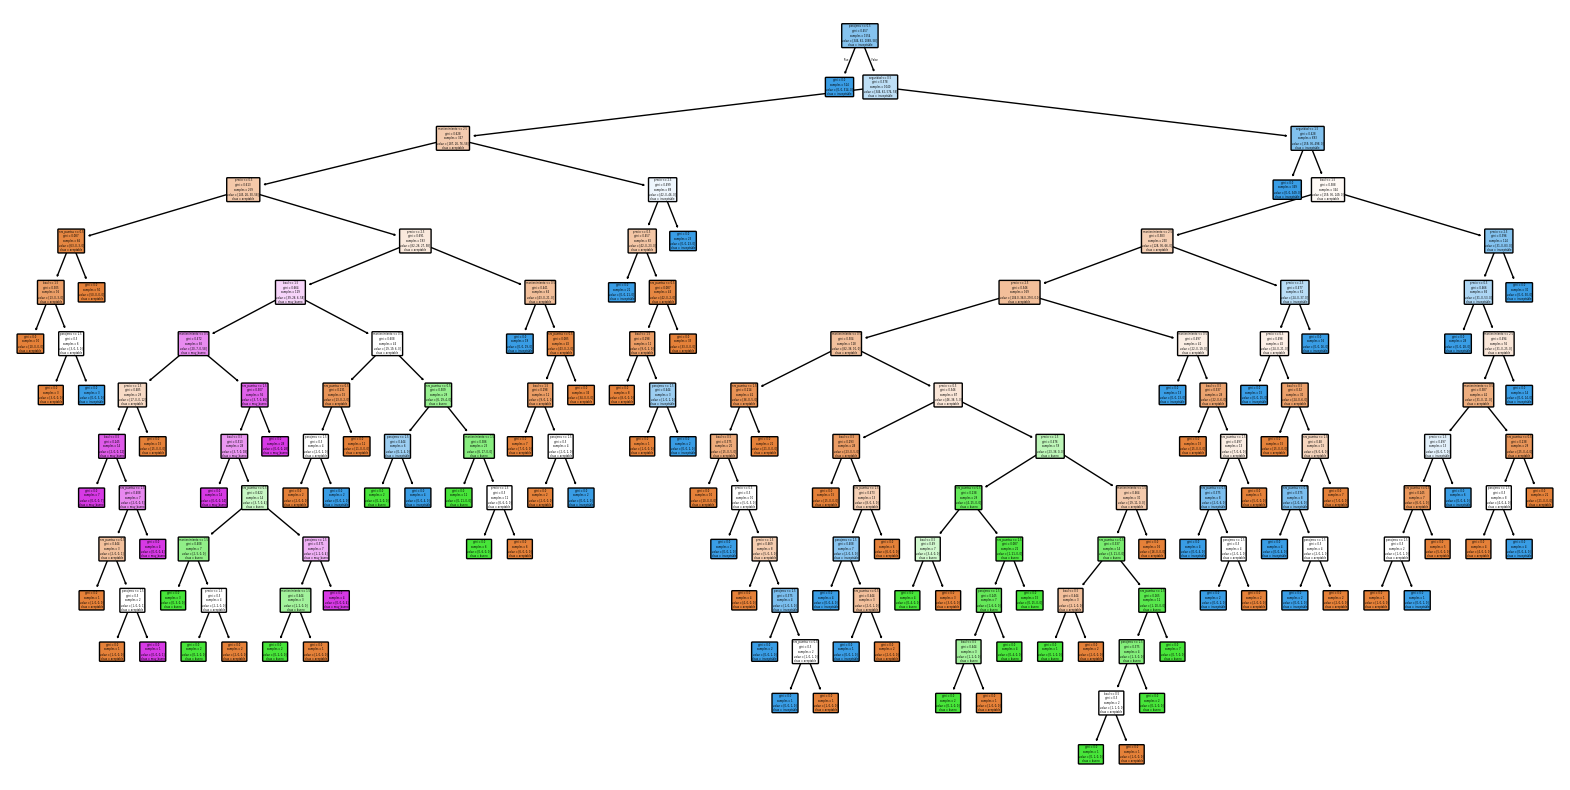

In [32]:
# make sure the 'tree' module is imported so tree.plot_tree is defined
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(arbol, feature_names=x_encoder.get_feature_names_out(), class_names=y_encoder.classes_, filled=True, rounded=True)
plt.show()
#no combiene este arbol tan profundo, pues se sobreajusta a los datos de entrenamiento del algortimo


In [33]:
print(f"profundidad  del arbol: {arbol.get_depth()}")
print(f'prametros usados en el entrenamiento: {arbol.get_params()}')

profundidad  del arbol: 14
prametros usados en el entrenamiento: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


el arbol a mayor profundidad, menos efectivo

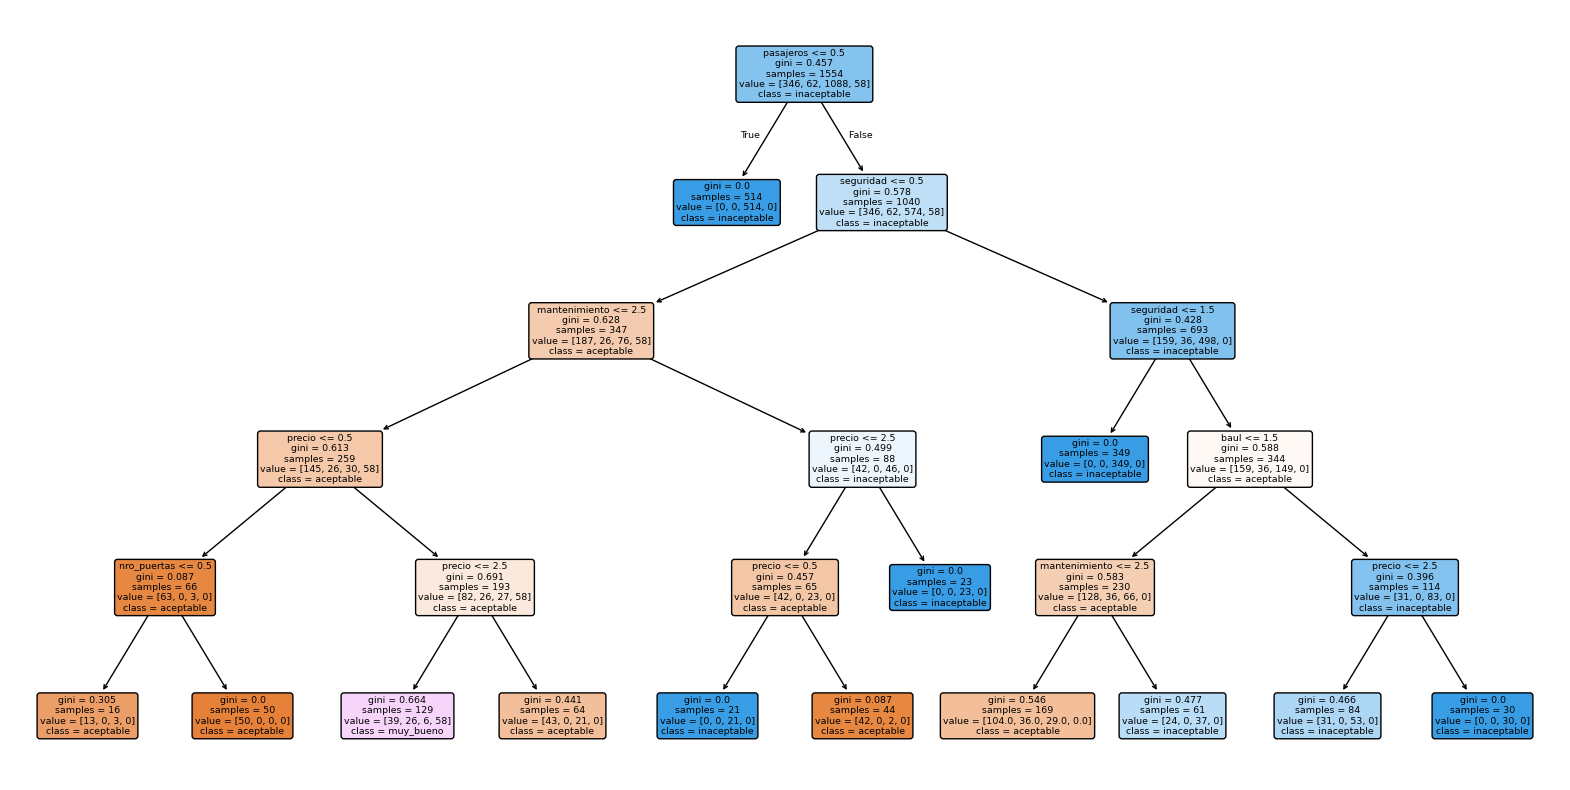

In [34]:
#reentrenaf pero con una profundiad maxima de 5
arbol = DecisionTreeClassifier(max_depth=5, random_state=123)
arbol.fit(X, Y)

#grafficar el arbol
plt.figure(figsize=(20,10))
tree.plot_tree(arbol, feature_names=x_encoder.get_feature_names_out(), class_names=y_encoder.classes_, filled=True, rounded=True)
plt.show()

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
#crear modelo
arbol = DecisionTreeClassifier(random_state=123)

#crear particiones estratificadas (no se disponen de 'groups' en este dataset)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

#realizr validacion cruzada
scores = cross_val_score(arbol, X, Y, cv=skf, scoring='accuracy')

#imprimir resulrados validacion cruzada
print(f'validacion cruzada scores: {scores}')
print(f"promedio puntajes:", scores.mean())
print(f"desviacion puntajes:", scores.std())

validacion cruzada scores: [0.97106109 0.96141479 0.97427653 0.97427653 0.98387097]
promedio puntajes: 0.9729799813297376
desviacion puntajes: 0.0072029356099813325


In [37]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
#crear modelo
arbol = DecisionTreeClassifier(random_state=123)

#crear particiones estratificadas (no se disponen de 'groups' en este dataset)
skf = StratifiedKFold(n_splits=8, shuffle=True, random_state=123)

#realizr validacion cruzada
scores = cross_val_score(arbol, X, Y, cv=skf, scoring='accuracy')

#imprimir resulrados validacion cruzada
print(f'validacion cruzada scores: {scores}')
print(f"promedio puntajes:", scores.mean())
print(f"desviacion puntajes:", scores.std())

validacion cruzada scores: [0.97948718 0.98461538 0.95876289 0.98453608 0.98453608 0.97938144
 0.98453608 0.97938144]
promedio puntajes: 0.9794045730901402
desviacion puntajes: 0.008156568192737336


In [38]:
arbol = DecisionTreeClassifier(max_depth=8, random_state=123)

arbol.fit(X, Y)

DecisionTreeClassifier(max_depth=8, random_state=123)

In [41]:
def predecir(X, x_enc, y_enc, modelo):
    #codificar la entrada
    x_num = x_enc.transform(x)
    
    #generar predicciones
    y_pred_num = modelo.predict(x_num)
    
    #transformacion inversa de la prediccion (de numero a categoria
    y = y_enc.inverse_transform(y_pred_num)
     #imprimir prediccion
    print(f'la prediccion es: {y}')
    print(y)
    
    return y

In [42]:
x_ts

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad
450,alto,muy_alto,2,4+,pequeno,media
1360,bajo,muy_alto,4,4,pequeno,alta
806,alto,bajo,3,4+,grande,baja
101,muy_alto,muy_alto,5+,4+,mediano,baja
951,medio,muy_alto,5+,2,grande,media
...,...,...,...,...,...,...
1064,medio,alto,5+,4,mediano,baja
1216,medio,bajo,3,2,pequeno,alta
630,alto,alto,5+,4,pequeno,media
497,alto,muy_alto,4,4,mediano,baja


In [43]:
y_pred = predecir(x_ts, x_encoder, y_encoder, arbol)    

la prediccion es: ['inaceptable' 'inaceptable' 'inaceptable' ... 'inaceptable' 'bueno'
 'muy_bueno']
['inaceptable' 'inaceptable' 'inaceptable' ... 'inaceptable' 'bueno'
 'muy_bueno']


In [44]:
def predecir(x, x_enc, y_enc, modelo, probs=False):
    # Codificar la entrada
    x_num = x_enc.transform(x)

    # Generar predicción
    if probs:
        y = modelo.predict_proba(x_num)
    else:
        y_pred = modelo.predict(x_num)
        y = y_enc.inverse_transform(y_pred)

    # Imprimir resultado
    print('Predicción:')
    print(y)

    return y

In [45]:
y_encoder.classes_

array(['aceptable', 'bueno', 'inaceptable', 'muy_bueno'], dtype=object)

In [46]:
y_pred = predecir(x_ts, x_encoder, y_encoder, arbol, probs=True)

Predicción:
[[0.         0.         1.         0.        ]
 [1.         0.         0.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.33333333 0.66666667 0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.53846154 0.         0.46153846 0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [1.         0.         0.         0.        ]
 

In [ ]:
y_ts